# Lecture 32: Ant Colony Optimization - Benchmarking

---

```{note}
Lecture 31 ran ACOR — the continuous-domain bridge — on the Ackley function. This lecture calibrates ACO in its **native** graph-based form directly on a TSPLIB instance, the same pattern Lectures 26 and 29 used for Simulated Annealing and the Genetic Algorithm. Because calibration now happens on a genuinely combinatorial benchmark, there is no encoding bridge needed at all here — unlike ACOR's archive, native ACO's pheromone parameters are exactly what Lecture 33's Chennai Metro Feeder Route capstone will use.
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Implement native graph-based Ant Colony Optimization and apply it to a TSPLIB instance.
2. Calibrate the evaporation rate on a small instance under a limited budget.
3. Compare how ACO's calibration scales to a larger instance against Simulated Annealing's and the Genetic Algorithm's scaling behaviour (Lectures 26, 29).

**Prerequisites**: Ant Colony Optimization - Algorithm (Lecture 31); Genetic Algorithm - Benchmarking (Lecture 29).

**Estimated time**: 50 minutes

---

## Native ACO on a TSPLIB Instance

Lecture 30 developed ACO's construction rule and pheromone update for a graph; Lecture 31 needed ACOR only because Ackley has no graph to construct on. `eil51` and `eil101` **are** graphs — every stop is a node, every pair of stops an edge — so native ACO, exactly as Lecture 30's pseudocode describes it, applies directly. No archive, no Gaussian sampling, no encoding bridge.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def aco(nodes, D, depot, alpha, beta, rho, Q, m, n=200, t=1e-9, tau_o=1.0):
    """Native graph-based ACO, implementing Lecture 30's pseudocode directly."""
    all_nodes = [depot] + list(nodes)
    tau = {(i, j): tau_o for i in all_nodes for j in all_nodes if i != j}
    eta = {(i, j): 1.0 / D[i, j] for i in all_nodes for j in all_nodes if i != j}

    def tour_length(tour):
        c = D[depot, tour[0]] + D[tour[-1], depot]
        for i in range(len(tour) - 1):
            c += D[tour[i], tour[i + 1]]
        return c

    def construct():
        unvisited, cur, tour = set(nodes), depot, []
        while unvisited:
            weights = np.array([tau[(cur, j)] ** alpha * eta[(cur, j)] ** beta for j in unvisited])
            probs = weights / weights.sum()
            nxt = random.choices(list(unvisited), weights=probs, k=1)[0]
            tour.append(nxt)
            unvisited.discard(nxt)
            cur = nxt
        return tuple(tour)

    s_b = construct()
    f_b = tour_length(s_b)
    F_b = [f_b]
    k, imp, converged = 0, float("inf"), False
    while not converged:
        tours = [construct() for _ in range(m)]
        costs = [tour_length(tr) for tr in tours]
        for key in tau:
            tau[key] *= (1 - rho)
        for tr, c in zip(tours, costs):
            full = [depot] + list(tr) + [depot]
            for i in range(len(full) - 1):
                a, b = full[i], full[i + 1]
                tau[(a, b)] += Q / c
                tau[(b, a)] += Q / c
        best_i = int(np.argmin(costs))
        if costs[best_i] < f_b:
            imp = f_b - costs[best_i]
            f_b = costs[best_i]
            s_b = tours[best_i]
        F_b.append(f_b)
        k += 1
        if k >= n or imp <= t:
            converged = True
    return s_b, F_b

# eil51: 51-city problem (Christofides/Eilon), TSPLIB, optimal = 426
EIL51 = [
    (37, 52), (49, 49), (52, 64), (20, 26), (40, 30), (21, 47), (17, 63), (31, 62), (52, 33), (51, 21),
    (42, 41), (31, 32), (5, 25), (12, 42), (36, 16), (52, 41), (27, 23), (17, 33), (13, 13), (57, 58),
    (62, 42), (42, 57), (16, 57), (8, 52), (7, 38), (27, 68), (30, 48), (43, 67), (58, 48), (58, 27),
    (37, 69), (38, 46), (46, 10), (61, 33), (62, 63), (63, 69), (32, 22), (45, 35), (59, 15), (5, 6),
    (10, 17), (21, 10), (5, 64), (30, 15), (39, 10), (32, 39), (25, 32), (25, 55), (48, 28), (56, 37),
    (30, 40),
]
EIL51_OPTIMAL = 426

def make_D(coords):
    n = len(coords)
    X = np.array([c[0] for c in coords], dtype=float)
    Y = np.array([c[1] for c in coords], dtype=float)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.hypot(X[i] - X[j], Y[i] - Y[j])
    return D, X, Y

D51, X51, Y51 = make_D(EIL51)
customers51 = list(range(1, len(EIL51)))

def tour_cost(tour, D):
    c = D[0, tour[0]] + D[tour[-1], 0]
    for i in range(len(tour) - 1):
        c += D[tour[i], tour[i + 1]]
    return c

print("aco() and eil51 ready.")

aco() and eil51 ready.


## Calibrating the Evaporation Rate

Fixing $\alpha=1$, $\beta=3$, $Q=10$, $m=10$ ants, a 100-iteration budget, averaged over 10 seeds — only $\rho$ changes.

In [2]:
def run_aco(rho, alpha=1, beta=3, Q=10, m=10, n_iters=100, n_seeds=10, D=D51, customers=customers51):
    results = []
    for seed in range(1, n_seeds + 1):
        random.seed(seed)
        np.random.seed(seed)
        s_b, F_b = aco(customers, D, 0, alpha=alpha, beta=beta, rho=rho, Q=Q, m=m, n=n_iters, t=1e-9)
        results.append(tour_cost(s_b, D))
    return np.array(results)

rho_results = {}
for rho in [0.05, 0.1, 0.3, 0.6, 0.9]:
    vals = run_aco(rho)
    rho_results[rho] = vals
    gap = (vals.mean() - EIL51_OPTIMAL) / EIL51_OPTIMAL * 100
    print(f"rho={rho:<5} -> mean cost = {vals.mean():.2f}   gap = {gap:.1f}%")

rho=0.05  -> mean cost = 479.18   gap = 12.5%
rho=0.1   -> mean cost = 471.07   gap = 10.6%
rho=0.3   -> mean cost = 464.23   gap = 9.0%
rho=0.6   -> mean cost = 466.37   gap = 9.5%
rho=0.9   -> mean cost = 473.83   gap = 11.2%


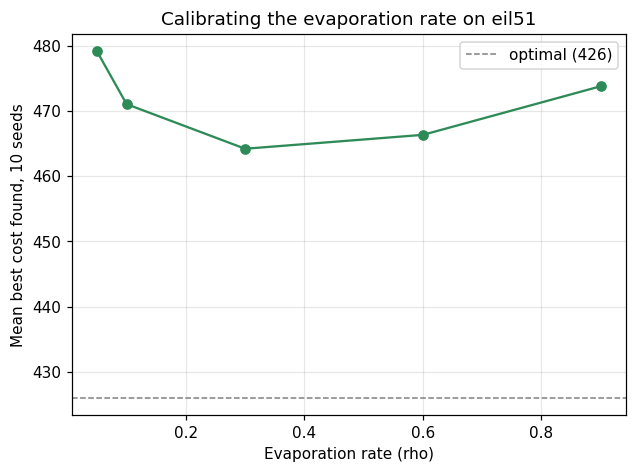

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(list(rho_results.keys()), [v.mean() for v in rho_results.values()], "o-", color="seagreen")
ax.axhline(EIL51_OPTIMAL, color="gray", linestyle="--", linewidth=1, label="optimal (426)")
ax.set_xlabel("Evaporation rate (rho)")
ax.set_ylabel("Mean best cost found, 10 seeds")
ax.set_title("Calibrating the evaporation rate on eil51")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

```{note}
$\rho=0.3$ is the clear best, with both lower and higher evaporation performing worse — the same interior sweet-spot shape Lecture 26 found for Simulated Annealing's cooling rate: too little evaporation lets early, possibly-lucky pheromone dominate construction indefinitely; too much forgets useful trails before they can accumulate.
```

---

## Benchmarking at Scale

In [4]:
EIL101 = [
    (41, 49), (35, 17), (55, 45), (55, 20), (15, 30), (25, 30), (20, 50), (10, 43), (55, 60), (30, 60),
    (20, 65), (50, 35), (30, 25), (15, 10), (30, 5), (10, 20), (5, 30), (20, 40), (15, 60), (45, 65),
    (45, 20), (45, 10), (55, 5), (65, 35), (65, 20), (45, 30), (35, 40), (41, 37), (64, 42), (40, 60),
    (31, 52), (35, 69), (53, 52), (65, 55), (63, 65), (2, 60), (20, 20), (5, 5), (60, 12), (40, 25),
    (42, 7), (24, 12), (23, 3), (11, 14), (6, 38), (2, 48), (8, 56), (13, 52), (6, 68), (47, 47),
    (49, 58), (27, 43), (37, 31), (57, 29), (63, 23), (53, 12), (32, 12), (36, 26), (21, 24), (17, 34),
    (12, 24), (24, 58), (27, 69), (15, 77), (62, 77), (49, 73), (67, 5), (56, 39), (37, 47), (37, 56),
    (57, 68), (47, 16), (44, 17), (46, 13), (49, 11), (49, 42), (53, 43), (61, 52), (57, 48), (56, 37),
    (55, 54), (15, 47), (14, 37), (11, 31), (16, 22), (4, 18), (28, 18), (26, 52), (26, 35), (31, 67),
    (15, 19), (22, 22), (18, 24), (26, 27), (25, 24), (22, 27), (25, 21), (19, 21), (20, 26), (18, 18),
    (35, 35),
]
EIL101_OPTIMAL = 629
D101, X101, Y101 = make_D(EIL101)
customers101 = list(range(1, len(EIL101)))

random.seed(42)
np.random.seed(42)
s_b, F_b = aco(customers101, D101, 0, alpha=1, beta=3, rho=0.3, Q=10, m=10, n=100, t=1e-9)
cost = tour_cost(s_b, D101)
print(f"Calibrated (rho=0.3), same budget m=10,n=100: cost = {cost:.2f}   "
      f"gap = {(cost - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%")

Calibrated (rho=0.3), same budget m=10,n=100: cost = 739.15   gap = 17.5%


In [5]:
for m, n_iters in [(10, 300), (20, 300)]:
    random.seed(42)
    np.random.seed(42)
    s_b, F_b = aco(customers101, D101, 0, alpha=1, beta=3, rho=0.3, Q=10, m=m, n=n_iters, t=1e-9)
    cost = tour_cost(s_b, D101)
    print(f"m={m:<3} n={n_iters:<4} -> cost = {cost:.2f}   gap = {(cost - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%")

m=10  n=300  -> cost = 722.17   gap = 14.8%
m=20  n=300  -> cost = 721.09   gap = 14.6%


**Interpretation.** ACO's calibrated evaporation rate carries over cleanly — even at the *same* budget it was calibrated at, the gap on `eil101` is already the smallest of any algorithm's naive transfer in this module, and it improves further with modestly more ants or iterations, without needing $\rho$ itself to change character. Across all three Benchmarking lectures, a consistent ranking emerges: **ACO's calibration transferred best, the Genetic Algorithm's transferred moderately (needing more budget but not a different setting), and Simulated Annealing's required an explicit change to the parameter itself.**

> **Managerial insight**: this ranking is not an accident of tuning — it tracks each algorithm's exploration mechanism. SA's single search thread depends entirely on its temperature schedule to avoid getting stuck, so a schedule miscalibrated for the instance size fails hard. GA and ACO both maintain many candidates at once (a population, a colony's parallel constructions), which cushions a suboptimal parameter choice by simply exploring more broadly regardless. **Algorithms that hedge across many simultaneous candidates degrade more gracefully under scale than algorithms that commit to one search thread at a time** — a concrete, evidence-based version of the tradeoff Lecture 23's taxonomy first raised in the abstract.

---

## Take-Away Exercises

### Exercise 1 — The Heuristic Weight at Scale

Set $\beta=0$ (pheromone only, no distance heuristic) and repeat this lecture's calibration and benchmarking-at-scale runs on `eil51` and `eil101`. Does removing the heuristic term hurt more, or less, at the larger scale than at the smaller one?

### Exercise 2 — Colony Size vs. Iterations

Matching total ant-constructions ($m \times$ iterations) roughly constant, compare $m=10$/300 iterations against $m=30$/100 iterations on `eil101`. Does it matter which one you scale up, the way it didn't much matter for the Genetic Algorithm (Lecture 29, Take-Away Exercise 1)?

---

## Circling Back

- **Lecture 31 (Ant Colony Optimization: Algorithm)**: applied ACOR's archive-based bridge to Ackley; `aco()` above is the *native* form Lecture 30's pseudocode always described, applied here for the first time in this arc, now that the module works with genuine routing graphs.
- **Lecture 26 (Simulated Annealing: Benchmarking)** and **Lecture 29 (Genetic Algorithm: Benchmarking)**: all three Benchmarking lectures ran the same calibrate-on-`eil51`, test-on-`eil101` experiment; the differences in how well each transferred are this module's clearest evidence for Lecture 23's taxonomy.

## Moving Forward

- **Lecture 33 (Transportation Engineering Problems - V)**: the first time any of these three algorithms is applied to the Chennai Metro Feeder Route — directly at the capacitated level, bringing `sa()`, `ga()`, and `aco()` together for a head-to-head comparison.

---

## Further Reading

- Reinelt, G. (1991). "TSPLIB — A Traveling Salesman Problem Library." *ORSA Journal on Computing*, 3(4), 376-384.
- Dorigo, M. and Stützle, T. (2004). *Ant Colony Optimization*. MIT Press.
- Stützle, T. and Hoos, H.H. (2000). "MAX-MIN Ant System." *Future Generation Computer Systems*, 16(8), 889-914.